In [1]:
from sklearn.svm import SVC
from ucimlrepo import fetch_ucirepo
from sklearn.metrics import (accuracy_score, precision_score,confusion_matrix, f1_score,recall_score, auc, roc_curve,ConfusionMatrixDisplay)
from sklearn.model_selection import train_test_split
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import time
import tracemalloc

In [2]:
phishing = fetch_ucirepo(id=327)
x = phishing.data.features
y = phishing.data.targets.values.ravel()
print(f"Dataset loaded: {x.shape[0]} samples, {x.shape[1]} features")

Dataset loaded: 11055 samples, 30 features


In [3]:
x_trn,x_tst,y_trn,y_tst = train_test_split(x,y,test_size=0.3,random_state=42)

In [4]:
scaler = joblib.load("scaler1.pkl")
x_trn = scaler.transform(x_trn)
x_tst = scaler.transform(x_tst)

In [5]:
svm = SVC(kernel='rbf', probability=True, random_state=42)
svm.fit(x_trn, y_trn)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [6]:
start = time.time()
y_pred = svm.predict(x_tst)
time1 = time.time() - start
print("SVM Prediction time:", time1)
tracemalloc.start()
_ = svm.predict(x_tst)
current_mem, peak_mem = tracemalloc.get_traced_memory()
tracemalloc.stop()
print(f"Memory Usage (current): {current_mem / 1024:.2f} KB")
print(f"Memory Usage (peak):    {peak_mem / 1024:.2f} KB")

SVM Prediction time: 0.708519697189331
Memory Usage (current): 27.80 KB
Memory Usage (peak):    813.41 KB


In [7]:
joblib.dump(svm, "svmModel.pkl")
print("Model saved as svmModel.pkl")

Model saved as svmModel.pkl


In [8]:
train_accuracy = svm.score(x_trn, y_trn)
test_accuracy  = accuracy_score(y_tst, y_pred)


print(f"Training Accuracy : {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Test Accuracy     : {test_accuracy:.4f}  ({test_accuracy*100:.2f}%)")
print(f"Difference        : {abs(train_accuracy - test_accuracy):.4f}")

if abs(train_accuracy - test_accuracy) < 0.02:
    print("Status            : No Overfitting (difference < 2%)")
elif abs(train_accuracy - test_accuracy) < 0.05:
    print("Status            : Slight Overfitting (difference 2-5%)")
else:
    print("Status            : Overfitting detected (difference > 5%)")

Training Accuracy : 0.9590 (95.90%)
Test Accuracy     : 0.9466  (94.66%)
Difference        : 0.0124
Status            : No Overfitting (difference < 2%)


In [9]:
accuracy  = accuracy_score(y_tst, y_pred)
precision = precision_score(y_tst, y_pred)
recall    = recall_score(y_tst, y_pred)
f1score   = f1_score(y_tst, y_pred)
confusionMatrix = confusion_matrix(y_tst, y_pred)

print("\n========== SVM RESULTS ==========")
print(f"Accuracy  = {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"Precision = {precision:.4f}  ({precision*100:.2f}%)")
print(f"Recall    = {recall:.4f}  ({recall*100:.2f}%)")
print(f"F1 Score  = {f1score:.4f}  ({f1score*100:.2f}%)")
print(f"\nPrediction Time : {time1:.6f} sec")
print(f"Peak Memory     : {peak_mem / 1024:.2f} KB")


========== SVM RESULTS ==========
Accuracy  = 0.9466  (94.66%)
Precision = 0.9468  (94.68%)
Recall    = 0.9603  (96.03%)
F1 Score  = 0.9535  (95.35%)

Prediction Time : 0.708520 sec
Peak Memory     : 813.41 KB


In [10]:
print(f"\nConfusion Matrix:\n{confusionMatrix}")


Confusion Matrix:
[[1326  102]
 [  75 1814]]


In [11]:
y_prob = svm.predict_proba(x_tst)[:, 1]
fpr, tpr, _ = roc_curve(y_tst, y_prob)
roc_auc = auc(fpr, tpr)
print(f"\nROC-AUC Score = {roc_auc:.4f}")


ROC-AUC Score = 0.9861


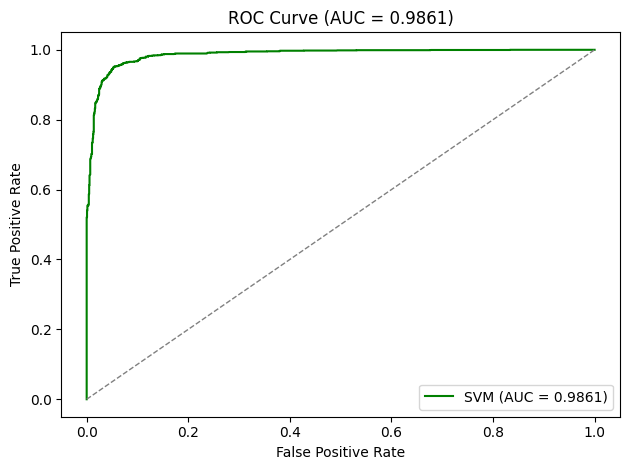

In [12]:
plt.plot(fpr, tpr,color="green",label=f"SVM (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (AUC = %0.4f)" % roc_auc)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("roc_svm.png", dpi=150)
plt.show()


In [13]:
summary = pd.DataFrame({
    "Model": ["SVM"],
    "Accuracy (%)":  [round(accuracy * 100, 2)],
    "Precision (%)": [round(precision * 100, 2)],
    "Recall (%)":    [round(recall * 100, 2)],
    "F1-Score (%)":  [round(f1score * 100, 2)],
    "ROC-AUC":       [round(roc_auc, 4)],
    "Pred Time (s)": [round(time1, 6)],
    "Peak Mem (KB)": [round(peak_mem / 1024, 2)]
})

print("\n========== SUMMARY TABLE ==========")
print(summary.to_string(index=False))


========== SUMMARY TABLE ==========
Model  Accuracy (%)  Precision (%)  Recall (%)  F1-Score (%)  ROC-AUC  Pred Time (s)  Peak Mem (KB)
  SVM         94.66          94.68       96.03         95.35   0.9861        0.70852         813.41
